In [11]:
# =======================
# Cell 1: Imports
# =======================
import os
import zipfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as F
from PIL import Image
import torchvision
from pycocotools.coco import COCO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [12]:
# =======================
# Cell 2: Hyperparameters
# =======================
hyperparams = {
    "learning_rate": 1e-4,
    "batch_size": 8,
    "num_epochs": 50,            # increase for better accuracy
    "num_classes": 91,           # COCO 80 classes + background
    "subset_train": 500,        # small subset for testing
    "subset_val": 500,
    "image_size": 256,
    "optimizer": "Adam",
    "visualize_num_images": 10   # NEW: number of images to visualize
}

print("🔧 Hyperparameters:")
for k, v in hyperparams.items():
    print(f"{k}: {v}")


🔧 Hyperparameters:
learning_rate: 0.0001
batch_size: 8
num_epochs: 50
num_classes: 91
subset_train: 500
subset_val: 500
image_size: 256
optimizer: Adam
visualize_num_images: 10


In [13]:
# =======================
# Cell 3: Download COCO Images and Annotations
# =======================
root = "./coco/val2017"
ann_dir = "./coco/annotations"
annFile = os.path.join(ann_dir, "instances_val2017.json")

# Download helper
def download_file(url, save_path):
    if not os.path.exists(save_path):
        print(f"Downloading {url} ...")
        urllib.request.urlretrieve(url, save_path)
        print("Download complete.")

# Download val images
if not os.path.exists(root):
    os.makedirs(root, exist_ok=True)
    url_images = "http://images.cocodataset.org/zips/val2017.zip"
    zip_path = "val2017.zip"
    download_file(url_images, zip_path)
    print("Extracting images...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("./coco")
    os.remove(zip_path)

# Download annotations
if not os.path.exists(annFile):
    os.makedirs(ann_dir, exist_ok=True)
    url_ann = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
    zip_path_ann = "annotations.zip"
    download_file(url_ann, zip_path_ann)
    print("Extracting annotations...")
    with zipfile.ZipFile(zip_path_ann, 'r') as zip_ref:
        zip_ref.extractall("./coco")
    os.remove(zip_path_ann)


In [14]:
# =======================
# Cell 4: Custom COCO Dataset
# =======================
class CocoSegmentationDataset(Dataset):
    def __init__(self, root, annFile, image_size=256, transform=None, subset_size=None):
        self.coco = COCO(annFile)
        self.root = root
        self.transform = transform
        self.img_ids = list(self.coco.imgs.keys())
        if subset_size is not None:
            self.img_ids = self.img_ids[:subset_size]
        self.image_size = image_size

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        img_info = self.coco.loadImgs(img_id)[0]
        path = os.path.join(self.root, img_info['file_name'])
        image = Image.open(path).convert("RGB")

        # Resize image
        if self.transform:
            image = self.transform(image)
        else:
            image = F.to_tensor(F.resize(image, (self.image_size, self.image_size)))

        # Create mask
        mask = np.zeros((self.image_size, self.image_size), dtype=np.uint8)
        for ann in anns:
            m = self.coco.annToMask(ann)
            m_resized = np.array(F.resize(torch.tensor(m, dtype=torch.uint8).unsqueeze(0),
                                          (self.image_size, self.image_size))).squeeze(0)
            mask = np.maximum(mask, m_resized)
        mask_tensor = torch.tensor(mask, dtype=torch.long)

        return image, mask_tensor


In [15]:
# =======================
# Cell 5: Datasets & DataLoaders
# =======================
transform = transforms.Compose([
    transforms.Resize((hyperparams["image_size"], hyperparams["image_size"])),
    transforms.ToTensor(),
])

train_dataset = CocoSegmentationDataset(root=root, annFile=annFile,
                                        image_size=hyperparams["image_size"],
                                        transform=transform,
                                        subset_size=hyperparams["subset_train"])
val_dataset = CocoSegmentationDataset(root=root, annFile=annFile,
                                      image_size=hyperparams["image_size"],
                                      transform=transform,
                                      subset_size=hyperparams["subset_val"])

train_loader = DataLoader(train_dataset, batch_size=hyperparams["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=hyperparams["batch_size"], shuffle=False)

coco_api = COCO(annFile)
print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")


loading annotations into memory...
Done (t=0.51s)
creating index...
index created!
loading annotations into memory...
Done (t=0.56s)
creating index...
index created!
loading annotations into memory...
Done (t=0.50s)
creating index...
index created!
Train size: 500, Val size: 500


In [16]:
# =======================
# Cell 6: Model Setup (UPDATED)
# =======================
from torchvision.models.segmentation import deeplabv3_resnet50

model = deeplabv3_resnet50(pretrained=True)

# 🔥 Updated classifier: added one extra layer for better feature refinement
model.classifier[4] = nn.Sequential(
    nn.Conv2d(256, 128, kernel_size=3, padding=1),   # NEW extra layer
    nn.BatchNorm2d(128),                             # normalize activations
    nn.ReLU(inplace=True),                           # non-linearity
    nn.Conv2d(128, hyperparams["num_classes"], kernel_size=1)  # final output layer
)

model = model.to(device)


In [17]:
# =======================
# Cell 7: Loss & Optimizer
# =======================
criterion = nn.CrossEntropyLoss()

if hyperparams["optimizer"] == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=hyperparams["learning_rate"])
else:
    optimizer = optim.SGD(model.parameters(), lr=hyperparams["learning_rate"], momentum=0.9)


In [18]:
# =======================
# Cell 8: Training Loop
# =======================
def train_model(model, train_loader, criterion, optimizer, num_epochs):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)["out"]
            loss = criterion(outputs, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

train_model(model, train_loader, criterion, optimizer, hyperparams["num_epochs"])


Epoch [1/50], Loss: 3.0446
Epoch [2/50], Loss: 2.0376
Epoch [3/50], Loss: 1.4911
Epoch [4/50], Loss: 1.0907
Epoch [5/50], Loss: 0.8227
Epoch [6/50], Loss: 0.6465
Epoch [7/50], Loss: 0.4725
Epoch [8/50], Loss: 0.3805
Epoch [9/50], Loss: 0.3211
Epoch [10/50], Loss: 0.2653
Epoch [11/50], Loss: 0.2238
Epoch [12/50], Loss: 0.2022
Epoch [13/50], Loss: 0.1803
Epoch [14/50], Loss: 0.1724
Epoch [15/50], Loss: 0.1489
Epoch [16/50], Loss: 0.1307
Epoch [17/50], Loss: 0.1182
Epoch [18/50], Loss: 0.1094
Epoch [19/50], Loss: 0.1024
Epoch [20/50], Loss: 0.0951
Epoch [21/50], Loss: 0.0896
Epoch [22/50], Loss: 0.0854
Epoch [23/50], Loss: 0.0821
Epoch [24/50], Loss: 0.0771
Epoch [25/50], Loss: 0.0809
Epoch [26/50], Loss: 0.0828
Epoch [27/50], Loss: 0.0991
Epoch [28/50], Loss: 0.2823
Epoch [29/50], Loss: 0.1823
Epoch [30/50], Loss: 0.1224
Epoch [31/50], Loss: 0.1084
Epoch [32/50], Loss: 0.1098
Epoch [33/50], Loss: 0.1010
Epoch [34/50], Loss: 0.0953
Epoch [35/50], Loss: 0.0745
Epoch [36/50], Loss: 0.0667
E

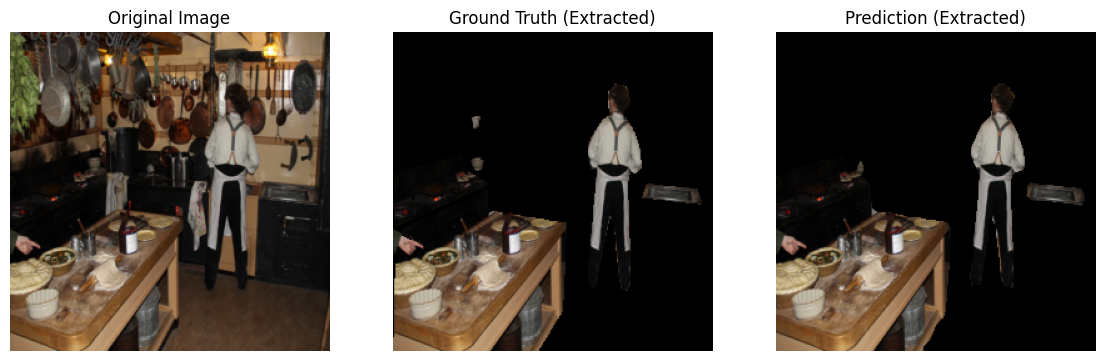

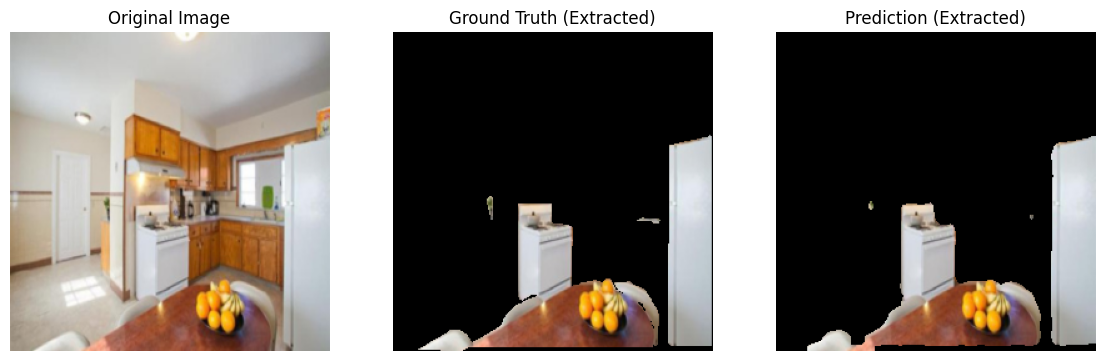

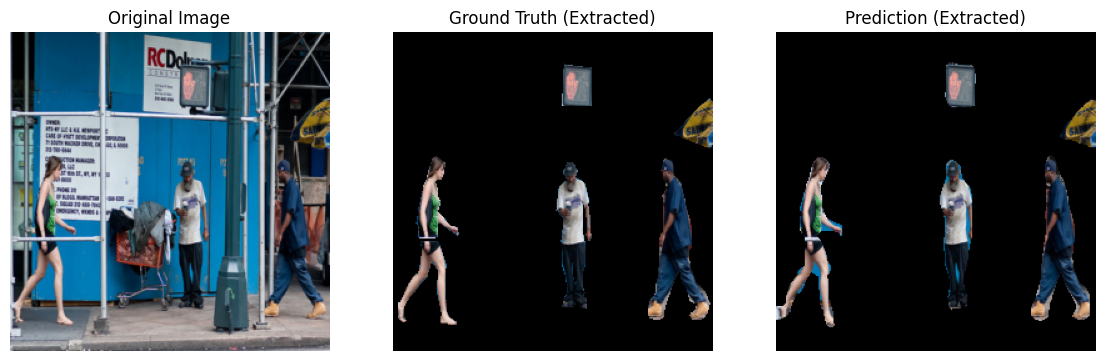

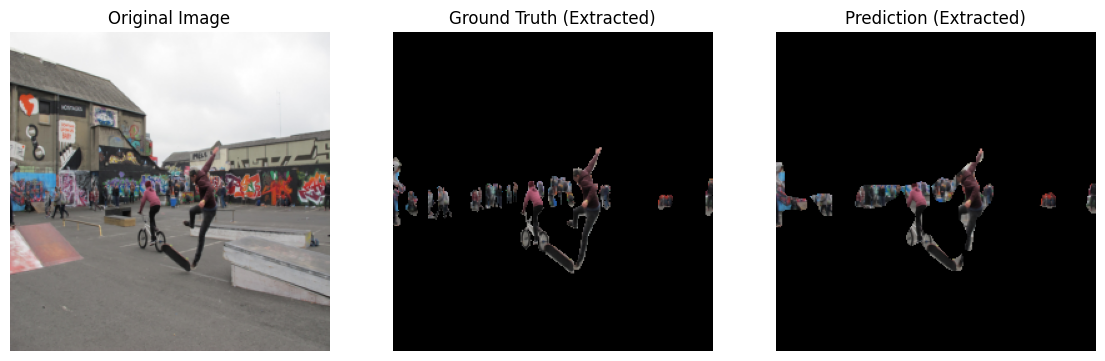

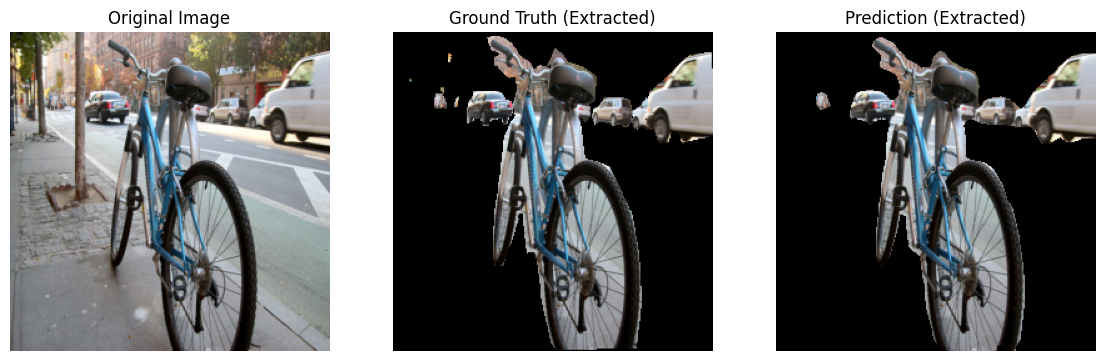

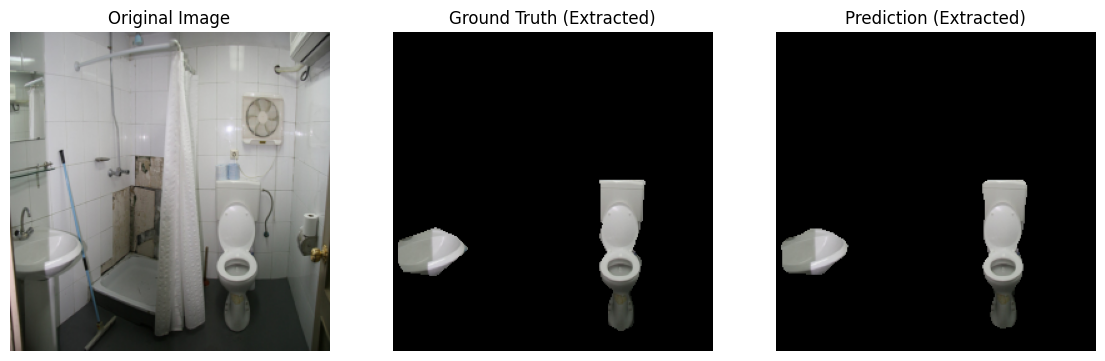

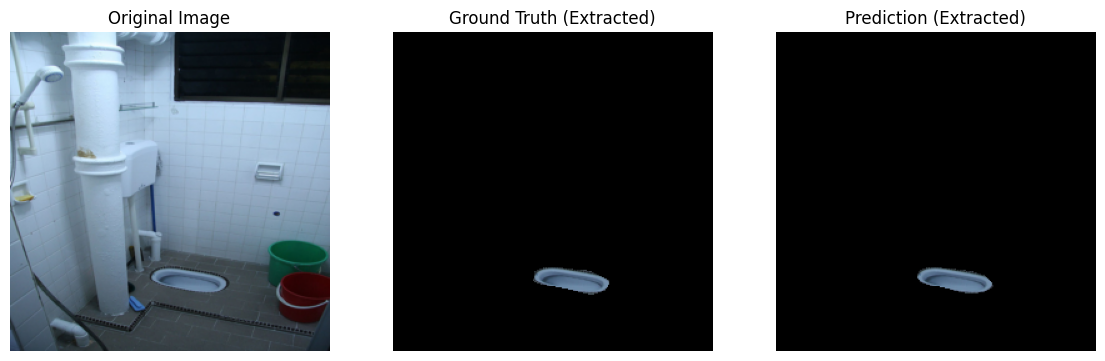

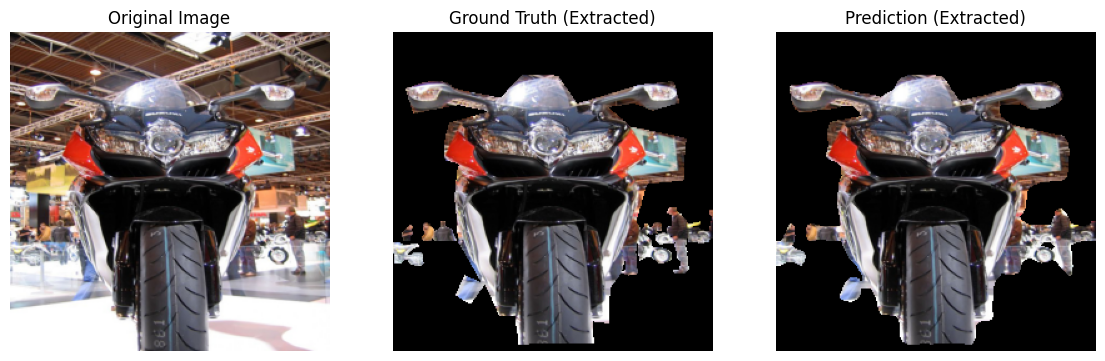

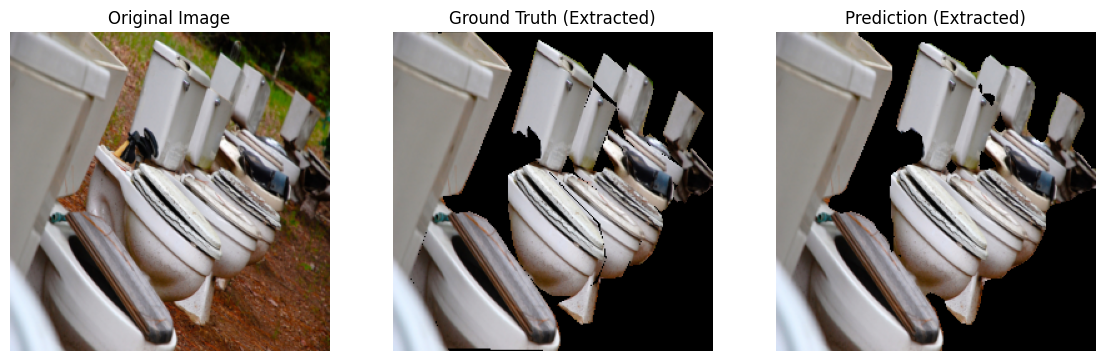

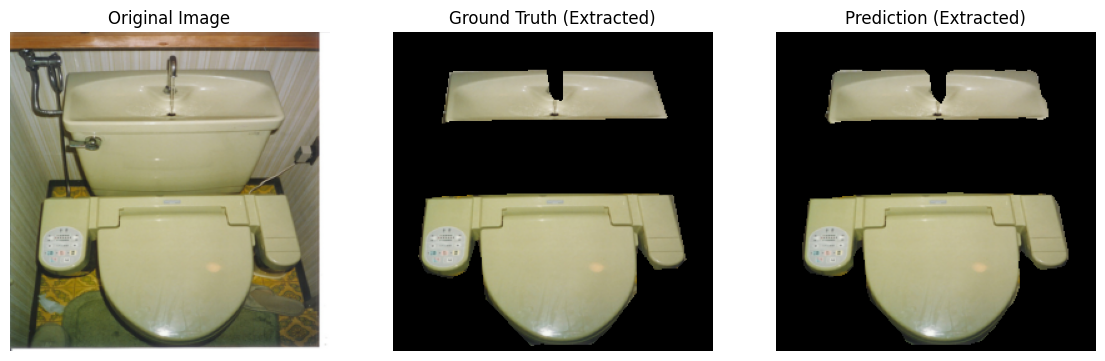

In [19]:
# =======================
# Visualization (Exact Object Extraction)
# =======================
def extract_object_rgb(image, mask):
    """
    Keep only the object region in original RGB, background is black.
    image: HWC (numpy, uint8)
    mask: HW (numpy, int)
    """
    obj = np.zeros_like(image, dtype=np.uint8)   # black background
    obj[mask > 0] = image[mask > 0]              # keep object pixels
    return obj


def visualize_final_predictions(model, data_loader, num_images=None):
    """
    Show Original Image | Ground Truth Extracted | Prediction Extracted
    """
    if num_images is None:
        num_images = hyperparams["visualize_num_images"]

    model.eval()
    shown = 0

    with torch.no_grad():
        for images, masks in data_loader:
            outputs = model(images.to(device))["out"]
            preds = outputs.argmax(1).cpu()

            for i in range(len(images)):
                if shown >= num_images:
                    return

                # Convert tensor -> numpy
                img = images[i].permute(1, 2, 0).numpy()
                img = (img * 255).astype(np.uint8)

                gt_mask = masks[i].numpy()
                pred_mask = preds[i].numpy()

                # Extract objects from original image
                gt_obj = extract_object_rgb(img, gt_mask)
                pred_obj = extract_object_rgb(img, pred_mask)

                # Show results
                fig, axs = plt.subplots(1, 3, figsize=(14, 5))
                axs[0].imshow(img); axs[0].set_title("Original Image"); axs[0].axis("off")
                axs[1].imshow(gt_obj); axs[1].set_title("Ground Truth (Extracted)"); axs[1].axis("off")
                axs[2].imshow(pred_obj); axs[2].set_title("Prediction (Extracted)"); axs[2].axis("off")
                plt.show()

                shown += 1

# Call after training
visualize_final_predictions(model, val_loader)


In [20]:
# =======================
# Updated Cell: Metrics (fixed TypeError)
# =======================
def compute_metrics(model, loader, num_classes):
    model.eval()
    iou_list, dice_list = [], []
    correct, total = 0, 0
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            outputs = model(images)["out"]
            preds = outputs.argmax(1).cpu()
            masks = masks.cpu()

            # Pixel accuracy
            correct += (preds == masks).sum().item()
            total += masks.numel()  # total number of pixels

            # IoU & Dice (for foreground classes)
            for cls in range(1, num_classes):
                intersection = ((preds==cls) & (masks==cls)).sum().item()
                union = ((preds==cls) | (masks==cls)).sum().item()
                pred_sum = (preds==cls).sum().item()
                mask_sum = (masks==cls).sum().item()
                if union > 0:
                    iou_list.append(intersection/union)
                    dice_list.append(2*intersection/(pred_sum + mask_sum))

    pixel_acc = 100 * correct / total
    mean_iou = 100 * np.mean(iou_list) if iou_list else 0
    mean_dice = 100 * np.mean(dice_list) if dice_list else 0

    print(f"Pixel Accuracy: {pixel_acc:.2f}%")
    print(f"Mean IoU: {mean_iou:.2f}%")
    print(f"Mean Dice Score: {mean_dice:.2f}%")

# Call the metrics
compute_metrics(model, val_loader, hyperparams["num_classes"])


Pixel Accuracy: 98.62%
Mean IoU: 95.31%
Mean Dice Score: 97.59%
